# 第 03 课：训练自回归分布 —— 采样与似然

**前情提要**（第 01、02 课）：

- 任何联合分布都能做链式法则分解：$p(x) = \prod_{i=1}^{N} p(x_i \mid x_{<i})$；
- **MADE 掩码网络**把"逐位计算条件概率"变成**一次前向传播**：掩码保证输出位 $i$ 只连接输入 $x_{<i}$。

本课回答三个问题：

1. 用这个模型做**似然评估**与**采样**，各需要多少次前向传播？——两者代价**不对称**（$O(1)$ vs $O(N)$），这是自回归模型最重要的计算性质；
2. 如何用**最大似然**训练它拟合一个手工 toy 分布，并验证收敛？
3. **归一化为什么是"免费"的**？——这个性质正是它后来能直接充当量子态 $|\psi(x)|^2$ 的原因（第 04 课的主角）。

环境：`jax + numpy + matplotlib`（固定随机种子，全部可复现）。

In [1]:
%matplotlib inline
import time
from itertools import product

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# 中文字体（macOS）
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Hiragino Sans GB", "Heiti TC", "STHeiti"]
plt.rcParams["axes.unicode_minus"] = False

N = 4  # 比特（自旋）数

## 1. 掩码网络：一次前向 = 全部条件概率

用上一课的 MADE 思路搭一个**单隐层**版本：$N=4$ 个输入、48 个隐藏单元、4 个输出（每个输出给出"该位为 1"的 logit）。掩码规则回顾：

- 隐藏单元的"度数"在 $\{0,\dots,N-2\}$ 中循环，它只连接度数 $\le$ 自己的输入位；
- 输出位 $i$ 只连接度数 $< i$ 的隐藏单元 $\Longrightarrow$ 输出 $i$ 只依赖 $x_{<i}$。

In [2]:
def make_masks(n_visible, n_hidden):
    '严格自回归的 MADE 掩码（第 02 课的精简单隐层版）'
    d_in = np.arange(n_visible)                              # 输入位 i 的度数 = i
    d_hidden = np.arange(n_hidden) % max(n_visible - 1, 1)   # 隐藏单元度数 ∈ {0,...,N-2}
    d_out = np.arange(n_visible)                             # 输出位 i 的度数 = i
    W1_mask = (d_hidden[:, None] >= d_in[None, :]).astype(np.float32)   # 隐藏层
    W2_mask = (d_out[:, None] > d_hidden[None, :]).astype(np.float32)   # 输出层（严格小于！）
    return [W1_mask, W2_mask]

MASKS = [jnp.array(m) for m in make_masks(N, n_hidden=48)]

def init_params(key, scale=0.3):
    keys = jax.random.split(key, len(MASKS))
    params = []
    for m, k in zip(MASKS, keys):
        W = jax.random.normal(k, m.shape) * scale
        b = jnp.zeros(m.shape[0])
        params.append((W, b))
    return params

def forward(params, x):
    'x: (B, N) ∈ {0,1}。返回 (B, N)：每一位 x_i 的条件分布 logit'
    h = x
    for l, (W, b) in enumerate(params):
        z = h @ (W * MASKS[l]).T + b          # 掩码乘在权重上：切断非法连接
        h = z if l == len(params) - 1 else jax.nn.relu(z)
    return h

def log_prob(params, x):
    'log p(x) = Σ_i log p(x_i | x_<i)。一次前向给出全部条件概率'
    logits = forward(params, x)
    # Bernoulli 对数似然：x·log σ(a) + (1-x)·log σ(-a)
    lp_bit = x * jax.nn.log_sigmoid(logits) + (1.0 - x) * jax.nn.log_sigmoid(-logits)
    return lp_bit.sum(axis=-1)                # (B,)

params0 = init_params(jax.random.PRNGKey(1))  # 固定种子的随机初始化，本课前半段都用它演示

先做个自检（第 02 课掩码性质的快速回顾）：

- **改变"未来位"不影响任何条件分布**——条件分布只看前缀；但 $\log p(x)$ 会变，因为第 4 位选了另一个分支；
- 改变"前缀位"则会改变后面位置的条件分布。

In [3]:
xa = jnp.array([[1, 0, 1, 0]], dtype=jnp.float32)
xb = jnp.array([[1, 0, 1, 1]], dtype=jnp.float32)   # 只改了最后一位（未来位）
xc = jnp.array([[1, 1, 1, 0]], dtype=jnp.float32)   # 只改了第二位（前缀位）

print("改未来位 x_3：条件 logit 是否完全一致 ->", np.allclose(forward(params0, xa), forward(params0, xb)))
print("  但 log p(x) 不同:", float(log_prob(params0, xa)[0]), "vs", float(log_prob(params0, xb)[0]))
print("改前缀位 x_1：前两位 logit 不变 ->",
      np.allclose(forward(params0, xa)[0, :2], forward(params0, xc)[0, :2]))
print("  后两位 logit 变了 ->", not np.allclose(forward(params0, xa)[0, 2:], forward(params0, xc)[0, 2:]))

改未来位 x_3：条件 logit 是否完全一致 -> True
  但 log p(x) 不同: -2.3155510425567627 vs -2.917201280593872
改前缀位 x_1：前两位 logit 不变 -> True
  后两位 logit 变了 -> True


### 一次前向读出所有条件概率

随便取一个构型，看一次前向给出的 4 个条件概率如何"链乘"出联合概率：

In [4]:
x_demo = jnp.array([[1, 0, 1, 1]], dtype=jnp.float32)
logits = np.asarray(forward(params0, x_demo))[0]
probs = 1.0 / (1.0 + np.exp(-logits))          # 每位 p(x_i = 1 | 前缀)

print(f"{'位 i':<6}{'前缀 x_<i':<14}{'x_i':<5}{'p(x_i=1|x_<i)':<16}{'本位贡献 log p'}")
prefix, lp = [], 0.0
for i in range(N):
    xi = int(x_demo[0, i])
    p1 = probs[i]
    contrib = np.log(p1) if xi == 1 else np.log(1.0 - p1)
    lp += contrib
    print(f"{i:<6}{str(prefix):<14}{xi:<5}{p1:<16.4f}{contrib:+.4f}")
    prefix.append(xi)
print(f"\n连乘（对数域求和）得 log p(x) = {lp:+.4f}  ->  p(x) = {np.exp(lp):.4f}")
print("与 log_prob 直接计算一致:", np.allclose(lp, float(log_prob(params0, x_demo)[0])))

位 i   前缀 x_<i       x_i  p(x_i=1|x_<i)   本位贡献 log p
0     []            1    0.5000          -0.6931
1     [1]           0    0.4521          -0.6016
2     [1, 0]        1    0.5577          -0.5839
3     [1, 0, 1]     1    0.3540          -1.0386

连乘（对数域求和）得 log p(x) = -2.9172  ->  p(x) = 0.0541
与 log_prob 直接计算一致: True


## 2. 两种基本操作的代价：似然 $O(1)$，采样 $O(N)$

| 操作 | 做法 | 前向次数 |
| --- | --- | --- |
| **似然评估** 一批构型 $\{x^{(b)}\}$ 的 $\log p$ | 整批一次喂入网络，读出全部条件概率再逐构型求和 | **1** |
| **采样** 生成一批构型 | 祖先采样：从 $p(x_0)$ 抽第 0 位 → 条件于前缀抽第 1 位 → …… 每生成一位前向一次 | **N** |

这个不对称性会随体系一起长大：$N=4$ 时是 $4:1$，$N=300$ 个自旋时是 $300:1$。但两者都远比"算归一化常数 $Z$"便宜——那需要枚举 $2^N$ 个态（见 §6）。

先写祖先采样，再实测计时。

In [5]:
def sample(params, key, n_samples):
    '祖先采样：逐位生成。生成第 i 位需要一次前向（读出第 i 个输出）'
    keys = jax.random.split(key, N)
    x = jnp.zeros((n_samples, N), dtype=jnp.float32)   # 未来位先置 0（掩码保证不影响前面的输出）
    for i in range(N):
        logits = forward(params, x)                    # O(1) 次前向 → 拿到当前位置的条件分布
        p1 = jax.nn.sigmoid(logits[:, i])
        bit = jax.random.bernoulli(keys[i], p1).astype(jnp.float32)
        x = x.at[:, i].set(bit)                        # 写入第 i 位，作为下一位的前缀
    return x

In [6]:
B = 20000
xs_random = jax.random.bernoulli(jax.random.PRNGKey(2), 0.5, (B, N)).astype(jnp.float32)

log_prob_jit = jax.jit(log_prob)
sample_jit = jax.jit(lambda p, k: sample(p, k, B))
_ = log_prob_jit(params0, xs_random)                    # 预编译
_ = sample_jit(params0, jax.random.PRNGKey(3))

t0 = time.perf_counter(); _ = log_prob_jit(params0, xs_random); t_like = time.perf_counter() - t0
t0 = time.perf_counter(); _ = sample_jit(params0, jax.random.PRNGKey(4)); t_samp = time.perf_counter() - t0

print(f"似然评估：{B} 个构型的 log p(x)   | 前向 {1} 次 | 用时 {t_like*1e3:7.1f} ms")
print(f"祖先采样：生成 {B} 个构型        | 前向 {N} 次 | 用时 {t_samp*1e3:7.1f} ms")
print(f"\n前向次数之比（采样/似然）= {N}；N 越大差距越大，但两者都远优于枚举 2^N 个态算 Z。")

似然评估：20000 个构型的 log p(x)   | 前向 1 次 | 用时     0.1 ms
祖先采样：生成 20000 个构型        | 前向 4 次 | 用时     0.2 ms

前向次数之比（采样/似然）= 4；N 越大差距越大，但两者都远优于枚举 2^N 个态算 Z。


**采样器正确性自检**：采样是 $O(N)$ 次前向、逐位串行的，容易写错。好在我们能 $O(1)$ 次前向算出模型在全空间的精确分布（16 个态），直接对比经验频率：

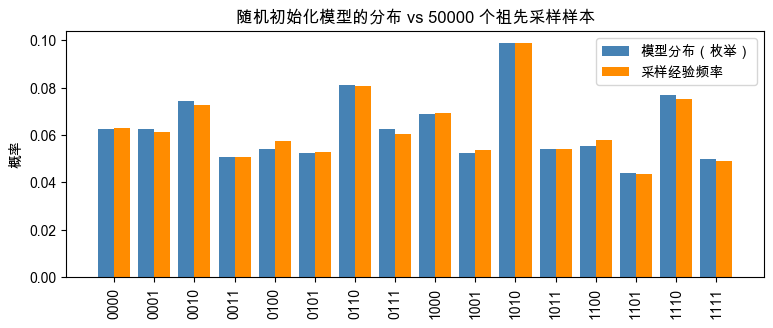

最大偏差 |经验频率 - 模型概率| = 0.0033，理论 3σ 统计涨落上界 ≈ 0.0040  → 量级一致，采样器正确


In [7]:
states_np = np.array(list(product([0, 1], repeat=N)), dtype=np.float32)   # 全部 16 个状态
labels = ["".join(str(int(b)) for b in s) for s in states_np]

p_model0 = np.exp(np.asarray(log_prob(params0, jnp.asarray(states_np))))
p_model0 /= p_model0.sum()                                # 模型分布（枚举）

xs = sample(params0, jax.random.PRNGKey(5), 50000)        # 祖先采样
# 与 states_np（product 序，x_0 为最高位）一致的编号
idx_emp = (np.asarray(xs) * (2.0 ** np.arange(N - 1, -1, -1))[None, :]).sum(-1).astype(int)
emp = np.zeros(2 ** N)
np.add.at(emp, idx_emp, 1.0 / len(xs))                    # 经验频率

fig, ax = plt.subplots(figsize=(9, 3.2))
w = 0.4
ax.bar(np.arange(2 ** N) - w / 2, p_model0, width=w, label="模型分布（枚举）", color="steelblue")
ax.bar(np.arange(2 ** N) + w / 2, emp, width=w, label="采样经验频率", color="darkorange")
ax.set_xticks(np.arange(2 ** N)); ax.set_xticklabels(labels, rotation=90)
ax.set_ylabel("概率"); ax.set_title("随机初始化模型的分布 vs 50000 个祖先采样样本")
ax.legend(); plt.show()
dev = np.abs(emp - p_model0)
three_sigma = (3.0 * np.sqrt(p_model0 * (1 - p_model0) / len(xs))).max()
print(f"最大偏差 |经验频率 - 模型概率| = {dev.max():.4f}，理论 3σ 统计涨落上界 ≈ {three_sigma:.4f}  → 量级一致，采样器正确")

## 3. Toy 目标分布：4-bit 双峰

目标分布取"双峰"形状——质量集中在 $0000$ 与 $1111$ 附近，按到最近峰的汉明距离指数衰减：

$$p_{\text{data}}(x) \;\propto\; e^{-3\, d\left(x,\ \{0000,\ 1111\}\right)}$$

$2^4 = 16$ 个状态可以全部枚举，所以训练前后都能画出**全空间条形图**，并计算 TV 距离与 KL 散度。

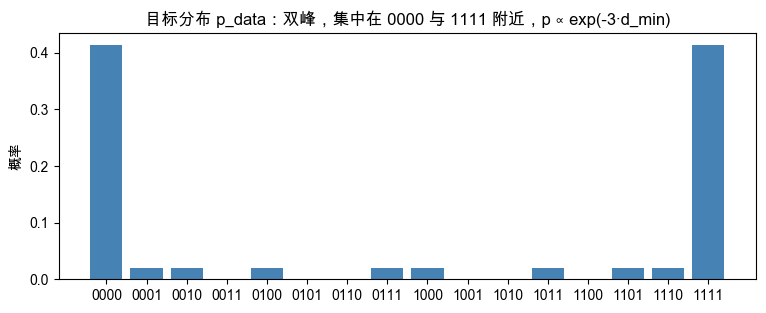

概率最大的 4 个状态：
   0000   0.4144
   1111   0.4144
   0001   0.0206
   0010   0.0206
全空间概率之和 = 1.000000


In [8]:
dist_to_modes = np.minimum(states_np.sum(1), N - states_np.sum(1))   # 到 {0000,1111} 的最近汉明距离
p_target = np.exp(-3.0 * dist_to_modes)
p_target /= p_target.sum()

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(labels, p_target, color="steelblue")
ax.set_ylabel("概率")
ax.set_title("目标分布 p_data：双峰，集中在 0000 与 1111 附近，p ∝ exp(-3·d_min)")
plt.show()

print("概率最大的 4 个状态：")
for k in np.argsort(-p_target)[:4]:
    print(f"   {labels[k]}   {p_target[k]:.4f}")
print(f"全空间概率之和 = {p_target.sum():.6f}")

## 4. 最大似然训练

最大似然 = 最小化负对数似然（NLL）：

$$\mathcal{L}(\theta) = -\,\mathbb{E}_{x \sim p_{\text{data}}}\big[\log p_\theta(x)\big] = -\,\mathbb{E}_{x \sim p_{\text{data}}}\Big[\sum_i \log p_\theta(x_i \mid x_{<i})\Big]$$

- **训练数据**：每个 step 从 $p_{\text{data}}$ 现采 1024 个样本（16 个状态按概率抽，相当于无限数据集）；
- **梯度**：对 $\log p_\theta(x)$ 整条链式分解用 JAX 自动微分；
- **优化器**：手写 Adam（几十行，内部看得见）。

注意这里的场景是"已知 $p_{\text{data}}$、手里有它的样本"——第 04 课会换成一个**没有数据、只有能量**的量子场景，但"自回归 = 结构合法的联合分布"这一框架完全不变。

In [9]:
def init_adam_state(params):
    return (jax.tree.map(jnp.zeros_like, params),
            jax.tree.map(jnp.zeros_like, params),
            jnp.zeros(()))

@jax.jit
def adam_update(params, state, grads, lr):
    m, v, t = state
    t = t + 1
    m = jax.tree.map(lambda m, g: 0.9 * m + 0.1 * g, m, grads)
    v = jax.tree.map(lambda v, g: 0.999 * v + 0.001 * g * g, v, grads)
    m_hat = jax.tree.map(lambda m: m / (1 - 0.9 ** t), m)
    v_hat = jax.tree.map(lambda v: v / (1 - 0.999 ** t), v)
    params = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + 1e-8),
                          params, m_hat, v_hat)
    return params, (m, v, t)

@jax.jit
def train_step(params, state, x, lr):
    def nll(p):
        return -log_prob(p, x).mean()      # 批量 log p：一次前向
    loss = nll(params)
    grads = jax.grad(nll)(params)
    params, state = adam_update(params, state, grads, lr)
    return params, state, loss

训练 800 步用时 0.3 s，NLL：2.8693 -> 1.4168


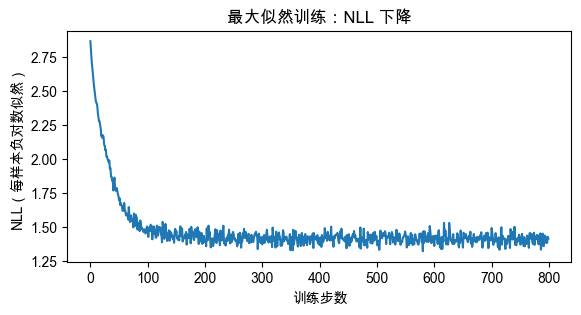

In [10]:
rng = np.random.default_rng(42)

params = params0                       # 就从前面那个随机初始化出发
state = init_adam_state(params)
n_steps, batch = 800, 1024
history = []
t_start = time.perf_counter()
for step in range(n_steps):
    lr = 0.01 if step < 400 else 0.002          # 后段降学习率精修
    idx = rng.choice(len(states_np), size=batch, p=p_target)   # 从目标分布采一批样本
    params, state, loss = train_step(params, state, jnp.asarray(states_np[idx]), jnp.float32(lr))
    history.append(float(loss))
t_train = time.perf_counter() - t_start
print(f"训练 {n_steps} 步用时 {t_train:.1f} s，NLL：{history[0]:.4f} -> {history[-1]:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(history)
ax.set_xlabel("训练步数"); ax.set_ylabel("NLL（每样本负对数似然）")
ax.set_title("最大似然训练：NLL 下降")
plt.show()

## 5. 收敛验证：模型分布 vs 目标分布（全空间枚举）

用 $O(1)$ 次前向枚举全部 16 个状态，计算

$$\mathrm{TV} = \tfrac{1}{2}\sum_x \big|p_{\text{model}}(x) - p_{\text{data}}(x)\big|, \qquad D_{\mathrm{KL}}(p_{\text{data}} \| p_{\text{model}}) = \sum_x p_{\text{data}}(x) \ln \frac{p_{\text{data}}(x)}{p_{\text{model}}(x)}$$

两者都为 0 当且仅当分布完全一致。

训练前（随机初始化）: TV = 0.7164, KL = 1.4565
训练后              : TV = 0.0073, KL = 0.0009


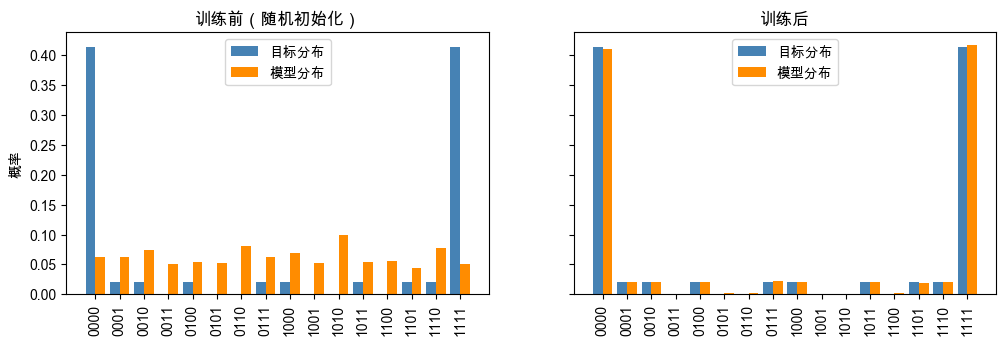

In [11]:
p_before = np.exp(np.asarray(log_prob(params0, jnp.asarray(states_np)))); p_before /= p_before.sum()
p_after = np.exp(np.asarray(log_prob(params, jnp.asarray(states_np))));  p_after /= p_after.sum()

tv_before = 0.5 * np.abs(p_before - p_target).sum()
tv_after = 0.5 * np.abs(p_after - p_target).sum()
kl_before = np.sum(p_target * np.log(p_target / np.clip(p_before, 1e-12, None)))
kl_after = np.sum(p_target * np.log(p_target / np.clip(p_after, 1e-12, None)))
print(f"训练前（随机初始化）: TV = {tv_before:.4f}, KL = {kl_before:.4f}")
print(f"训练后              : TV = {tv_after:.4f}, KL = {kl_after:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
w = 0.4
for ax, pm, title in [(axes[0], p_before, "训练前（随机初始化）"), (axes[1], p_after, "训练后")]:
    ax.bar(np.arange(2 ** N) - w / 2, p_target, width=w, label="目标分布", color="steelblue")
    ax.bar(np.arange(2 ** N) + w / 2, pm, width=w, label="模型分布", color="darkorange")
    ax.set_xticks(np.arange(2 ** N)); ax.set_xticklabels(labels, rotation=90)
    ax.set_title(title); ax.legend()
axes[0].set_ylabel("概率")
plt.show()

## 6. 关键洞察：归一化是"免费"的（自回归量子态的卖点）

自回归结构把归一化直接**焊进了架构**：每位条件分布是 sigmoid（自动归一化），全空间求和时逐位求和与连乘交换（对位数归纳）：

$$\sum_x p_\theta(x) = \sum_{x_0}\!\cdots\!\sum_{x_{N-1}} \prod_i p_\theta(x_i|x_{<i}) = \prod_i \underbrace{\sum_{x_i} p_\theta(x_i|x_{<i})}_{=1} = 1 \quad \text{对任意 } \theta \text{ 成立}$$

传统 NQS（RBM / 普通 FFNN）做不到：网络给出的是**未归一化**的密度 $\rho_\theta(x) = |\psi_\theta(x)|^2$，要得到概率必须除以**配分函数**

$$Z = \sum_x \rho_\theta(x)$$

——一个和模型一样难算的量。下面用 4-bit 数值例子把对比摆出来。

In [12]:
print("【自回归模型（本课的模型）】")
print(f"  训练前  Σ_x p(x) = {p_before.sum():.10f}")
print(f"  训练后  Σ_x p(x) = {p_after.sum():.10f}    ← 任意参数下恒等于 1，无需任何计算")

# 对照：传统 NQS 的写法 —— 振幅由普通（无掩码）FFNN 给出，|ψ|² 未归一化
k1, k2 = jax.random.split(jax.random.PRNGKey(6))
W1 = jax.random.normal(k1, (32, N)) * 0.5
b1 = jnp.zeros(32)
W2 = jax.random.normal(k2, (1, 32)) * 0.5
b2 = jnp.zeros(1)

def plain_mlp(x):
    '普通 FFNN：每个构型输出一个实值振幅 ψ(x)，没有任何自回归结构'
    return (jnp.tanh(x @ W1.T + b1) @ W2.T + b2)[:, 0]

rho = np.asarray(plain_mlp(jnp.asarray(states_np))) ** 2    # 未归一化的 |ψ|²
Z = rho.sum()
print("\n【传统 NQS 写法：普通 FFNN 振幅，无归一化】")
print(f"  Σ_x |ψ(x)|² = Z = {Z:.4f}   ← 不是 1，而且随参数任意变化！")
print(f"  真实概率 p(x) = |ψ(x)|² / Z：N=4 时枚举 16 个态即可算出 Z；")
print(f"  但 N=40 时要加 2^40 ≈ 10^12 个态，N=300 时 Z 根本不可能枚举。")
print("\n结论：自回归把'算 Z'这个指数级难题变成了 0 成本 —— 这正是第 04 课一切便利的来源。")

【自回归模型（本课的模型）】
  训练前  Σ_x p(x) = 1.0000000000
  训练后  Σ_x p(x) = 1.0000000000    ← 任意参数下恒等于 1，无需任何计算



【传统 NQS 写法：普通 FFNN 振幅，无归一化】
  Σ_x |ψ(x)|² = Z = 16.2268   ← 不是 1，而且随参数任意变化！
  真实概率 p(x) = |ψ(x)|² / Z：N=4 时枚举 16 个态即可算出 Z；
  但 N=40 时要加 2^40 ≈ 10^12 个态，N=300 时 Z 根本不可能枚举。

结论：自回归把'算 Z'这个指数级难题变成了 0 成本 —— 这正是第 04 课一切便利的来源。


**这对 VMC 意味着什么**（第 04 课的全部动机）：

- **传统 NQS 的 VMC**：从 $|\psi|^2/Z$ 采样只能靠 **MCMC**（要 burn-in、样本自相关、还得调接受率），因为 $Z$ 未知；
- **自回归 NQS**：$p_\theta(x)$ **本身就是**归一化的采样分布 → 直接祖先采样得到**独立**样本；$\log p_\theta(x)$ 还能 $O(1)$ 次前向精确评估。

也就是说：变分能量、局域能量、梯度公式**全部原样保留**，唯一被换掉的是采样器——从"近似 + 相关"换成"精确 + 独立"。这就是自回归量子态最大的卖点。

## 7. 小结 + 预告

**本课要点**

1. **似然评估 = 1 次前向**（批量任意大）；**祖先采样 = N 次前向**（逐位串行）。训练用前者，生成用后者，两者代价不对称；
2. **最大似然**（最小化 NLL）+ Adam，几百步就把 4-bit 双峰学到 TV ≈ 0.01、KL ≈ 0.002（训练前 TV ≈ 0.63）；
3. **归一化免费**：$\sum_x p_\theta(x) \equiv 1$ 对任意参数成立；传统 NQS 的配分函数 $Z$ 是指数级难题。自回归 NQS 的 VMC 只需要把 MCMC 采样器换成精确的祖先采样。

**思考题**

1. 如果去掉掩码（普通 FFNN 直接输出 4 个 logit 当"条件概率"），"一次前向给出合法联合分布"还成立吗？坏在哪里？
2. 祖先采样中，不同**样本**之间可以并行，不同**位置**之间为什么不行？第 $i$ 位的采样必须等什么？
3. （为下一课铺垫）如果目标不是"拟合样本"，而是"最小化某个能量期望"——没有数据、梯度来自能量本身，训练框架要怎么改？

**预告**：下一课把"分布"换成"量子态振幅"：$|\psi_\theta(x)|^2 = p_\theta(x)$、$\psi_\theta = \sqrt{p_\theta} \ge 0$。用横场 Ising 模型（N=4）跑一遍**完整的 VMC**——局域能量 $E_{\text{loc}}$、能量梯度、Adam 优化，并与精确对角化对答案。